# 실습 3-2 : GBM, XGBoost, LightGBM, CatBoost

#### **<실습 내용>**

1. 분류 (Classification) - MachineFailure 데이터
- GBM, XGBoost, LightGBM, CatBoost 모델 학습 및 하이퍼 파라미터 최적화
- 모델 결과 비교 

2. 회귀 (Regression) - Concrete 데이터
- GBM, XGBoost, LightGBM, CatBoost 모델 학습 및 하이퍼 파라미터 최적화
- 모델 결과 비교 

## 분석 준비

### 주요 라이브러리 호출

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


def setup_korean_font():
    """matplotlib/seaborn 한글 폰트 적용. sns.set_theme() 호출 후 재호출 필요."""
    _korean_fonts = ["Malgun Gothic", "NanumGothic", "AppleGothic", "Gulim"]
    _available = {f.name for f in fm.fontManager.ttflist}
    for _font in _korean_fonts:
        if _font in _available:
            plt.rcParams["font.family"] = _font
            break
    plt.rcParams["axes.unicode_minus"] = False


sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.05)
setup_korean_font()

### 성능 평가 함수 정의

In [2]:
# 분류 성능 평가 함수
def get_classscore(real, pred):
    print("Accuracy  : %.3f" % accuracy_score(real, pred))
    print("Precision : %.3f" % precision_score(real, pred))
    print("Recall    : %.3f" % recall_score(real, pred))
    print("F1-score  : %.3f" % f1_score(real, pred))

# 회귀 성능 평가 함수
def get_regscore(true, pred):
    print("MSE       : %.3f" % mean_squared_error(true, pred))
    print("RMSE      : %.3f" % np.sqrt(mean_squared_error(true, pred)))
    print("MAE       : %.3f" % mean_absolute_error(true, pred))
    print("R-squared : %.3f" % r2_score(true, pred))

---

## 1. 분류 (Classification) - MachineFailure 데이터

### 데이터 전처리

In [3]:
MF_Data = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day3-2_cls_data.csv"))

# 입출력 변수 분할 및 전처리
Y = MF_Data["Failure"]
X = MF_Data.drop(["Failure"], axis=1)

X["Measure2"] = X["Measure2"].astype("category")
X["Measure3"] = X["Measure3"].astype("category")
X = pd.get_dummies(X)
data_columns = X.columns

Y = Y.replace({"No": 0, "Yes": 1})

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=0, stratify=Y)
print("학습 데이터 :", X_train.shape)
print("테스트 데이터 :", X_test.shape)

학습 데이터 : (5530, 31)
테스트 데이터 : (2370, 31)


C:\Users\Admin\AppData\Local\Temp\ipykernel_14960\4124609564.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y = Y.replace({"No": 0, "Yes": 1})


---

### 1-1) GBM

> **GBM (Gradient Boosting Machine)** 은 이전 라운드의 베이스 모델이 잘못 예측한 **잔차(residual)** 를 다음 라운드의 베이스 모델이 학습하는 순차적 앙상블 기법임

In [4]:
GBM_cls = GradientBoostingClassifier()
GBM_cls.fit(X_train, Y_train)
GBM_cls_pred = GBM_cls.predict(X_test)
get_classscore(Y_test, GBM_cls_pred)

Accuracy  : 0.997
Precision : 0.850
Recall    : 0.773
F1-score  : 0.810


#### 변수 중요도 시각화

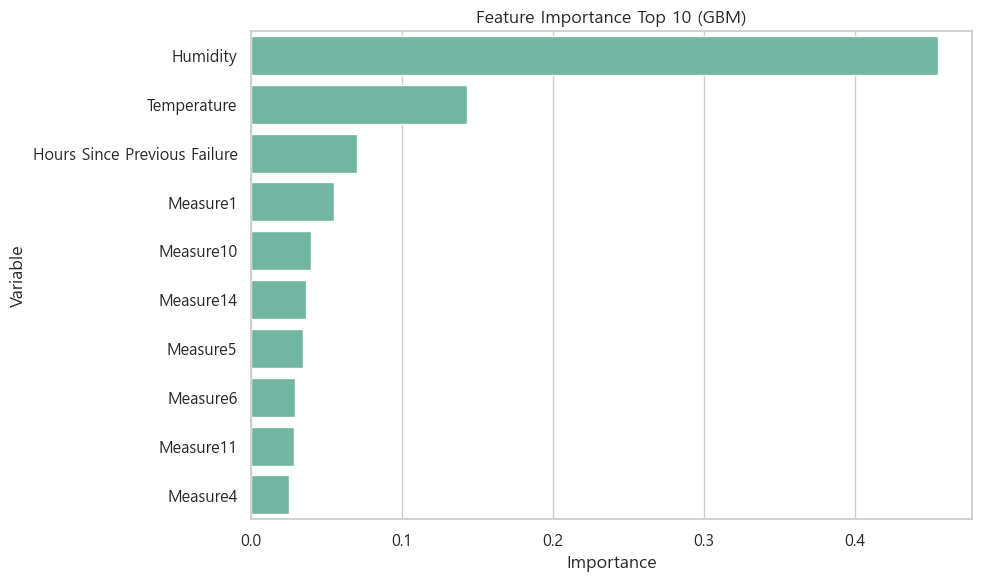

In [5]:
var_imp_gbm_cls = pd.DataFrame({"Variable": X_train.columns, "Importance": GBM_cls.feature_importances_})
imp_top10_gbm_cls = var_imp_gbm_cls.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Variable", data=imp_top10_gbm_cls)
plt.title("Feature Importance Top 10 (GBM)")
plt.tight_layout()
plt.show()

#### 하이퍼 파라미터 최적화

> GBM의 주요 하이퍼 파라미터:
>
> | 하이퍼파라미터 | 기본값 | 하이퍼파라미터 설명 |
> |:---:|:---:|:---:|
> | learning_rate | 0.1 | 이전 오차를 얼마나 반영할지 결정 |
> | subsample | 1.0 | 각 트리 학습 시 사용할 데이터 비율 |
> | validation_fraction | 0.1 | 조기 종료를 위한 검증 데이터 비율 |
> | n_iter_no_change | None | 성능 향상이 없을 경우 학습 중단 |
> | n_estimators | 100 | 생성할 트리의 개수 |
> | max_depth | 3 | 트리의 최대 깊이 |
> | max_leaf_nodes | None | 리프 노드의 최대 개수 |
> | min_samples_leaf | 1 | 리프 노드가 되기 위한 최소 샘플 수 |
> | min_samples_split | 2 | 노드를 분할하기 위한 최소 샘플 수 |

In [6]:
params_gbm_cls = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5],
    "min_samples_leaf": [1, 5],
    "subsample": [0.8, 1.0]
}

grid_gbm_cls = GridSearchCV(
    GradientBoostingClassifier(random_state=0),
    param_grid=params_gbm_cls, cv=3, scoring="f1", n_jobs=-1
)
grid_gbm_cls.fit(X_train, Y_train)

print("최적 파라미터:", grid_gbm_cls.best_params_)
print("최적 F1-score (CV): %.4f" % grid_gbm_cls.best_score_)

최적 파라미터: {'learning_rate': 0.01, 'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 300, 'subsample': 0.8}
최적 F1-score (CV): 0.8291


In [7]:
best_gbm_cls_pred = grid_gbm_cls.predict(X_test)
print("[GBM - 최적 모델]")
get_classscore(Y_test, best_gbm_cls_pred)

[GBM - 최적 모델]
Accuracy  : 0.997
Precision : 0.944
Recall    : 0.773
F1-score  : 0.850


---

### 1-2) XGBoost

> **XGBoost**는 GBM에 **트리 규제항(Regularization)** 을 추가하여 과적합을 방지하는 모델임

In [8]:
XGB_cls = XGBClassifier()
XGB_cls.fit(X_train, Y_train)
XGB_cls_pred = XGB_cls.predict(X_test)
get_classscore(Y_test, XGB_cls_pred)

Accuracy  : 0.997
Precision : 1.000
Recall    : 0.682
F1-score  : 0.811


#### 변수 중요도 시각화

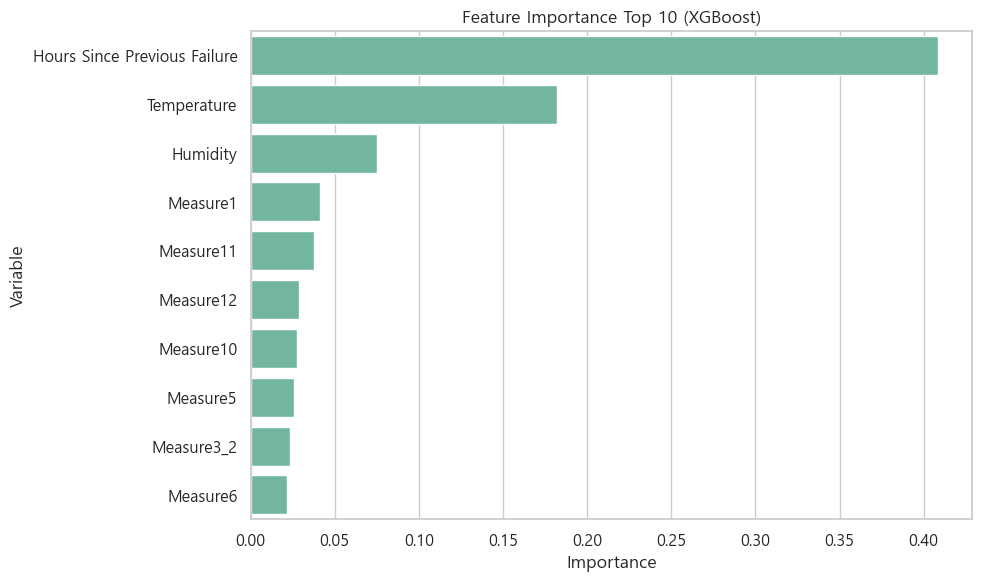

In [9]:
var_imp_xgb_cls = pd.DataFrame({"Variable": X_train.columns, "Importance": XGB_cls.feature_importances_})
imp_top10_xgb_cls = var_imp_xgb_cls.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Variable", data=imp_top10_xgb_cls)
plt.title("Feature Importance Top 10 (XGBoost)")
plt.tight_layout()
plt.show()

#### 하이퍼 파라미터 최적화

> XGBoost의 주요 하이퍼 파라미터:
>
> | 하이퍼파라미터 | 기본값 | 하이퍼파라미터 설명 |
> |:---:|:---:|:---:|
> | colsample_bytree | 1.0 | 각 트리 학습 시 사용할 변수 비율 |
> | gamma | 0.0 | 추가 분할을 수행할 최소 기준 값 (클수록 단순한 모델 생성) |
> | reg_lambda | 1.0 | 과적합 방지를 위한 정규화 강도 |
> | n_estimators | 100 | 생성할 트리의 개수 |
> | max_depth | 6 | 트리의 최대 깊이 |
> | learning_rate | 0.1 | 각 트리가 이전 오차를 얼마나 반영할지 결정 |

In [10]:
params_xgb_cls = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5],
    "gamma": [0, 2],
    "reg_lambda": [1, 5],
    "subsample": [0.8, 1.0]
}

grid_xgb_cls = GridSearchCV(
    XGBClassifier(random_state=0, eval_metric="logloss"),
    param_grid=params_xgb_cls, cv=3, scoring="f1", n_jobs=-1
)
grid_xgb_cls.fit(X_train, Y_train)

print("최적 파라미터:", grid_xgb_cls.best_params_)
print("최적 F1-score (CV): %.4f" % grid_xgb_cls.best_score_)

최적 파라미터: {'gamma': 0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'reg_lambda': 1, 'subsample': 1.0}
최적 F1-score (CV): 0.8335


In [11]:
best_xgb_cls_pred = grid_xgb_cls.predict(X_test)
print("[XGBoost - 최적 모델]")
get_classscore(Y_test, best_xgb_cls_pred)

[XGBoost - 최적 모델]
Accuracy  : 0.997
Precision : 1.000
Recall    : 0.727
F1-score  : 0.842


---

### 1-3) LightGBM

> **LightGBM**은 GBM의 학습 속도를 개선한 모델로, 다음 기술을 사용함
> - **GOSS** (Gradient-Based One Side Sampling): 잔차가 큰 데이터를 우선 학습하여 학습 데이터를 줄임
> - **Leaf-Wise Tree Growth**: 가장 큰 Loss를 가진 노드만 분할하여 트리 생성 속도를 높임
> - XGBoost 대비 최대 **38배 빠른 학습 속도**를 보이면서 비슷하거나 높은 정확도를 달성함

In [12]:
LGBM_cls = LGBMClassifier(verbose=-1)
LGBM_cls.fit(X_train, Y_train)
LGBM_cls_pred = LGBM_cls.predict(X_test)
get_classscore(Y_test, LGBM_cls_pred)

Accuracy  : 0.998
Precision : 1.000
Recall    : 0.773
F1-score  : 0.872


#### 변수 중요도 시각화

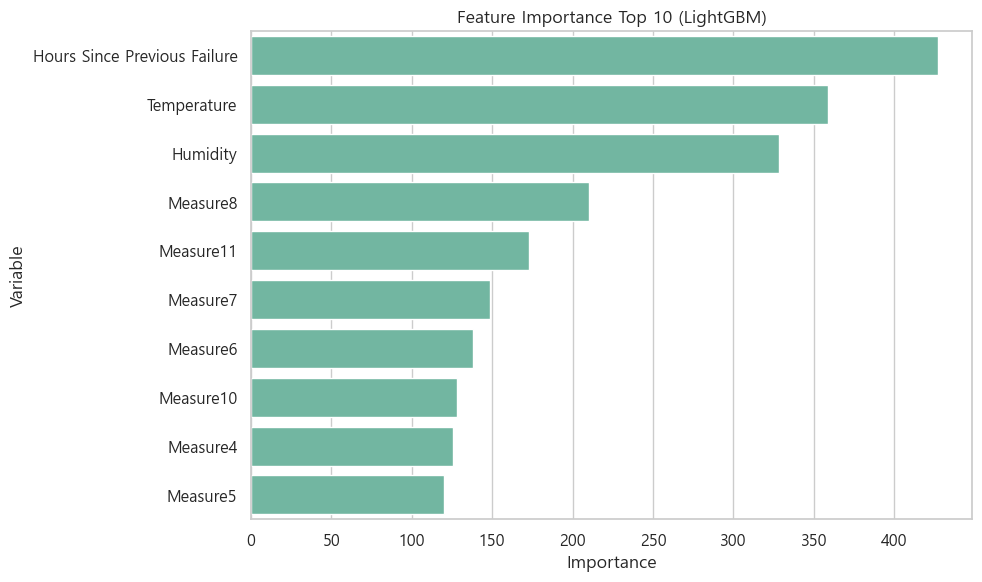

In [13]:
var_imp_lgbm_cls = pd.DataFrame({"Variable": X_train.columns, "Importance": LGBM_cls.feature_importances_})
imp_top10_lgbm_cls = var_imp_lgbm_cls.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Variable", data=imp_top10_lgbm_cls)
plt.title("Feature Importance Top 10 (LightGBM)")
plt.tight_layout()
plt.show()

#### 하이퍼 파라미터 최적화

> LightGBM의 주요 하이퍼 파라미터:
>
> | 하이퍼파라미터 | 기본값 | 하이퍼파라미터 설명 |
> |:---:|:---:|:---:|
> | num_leaves | 31 | 하나의 트리가 가질 수 있는 최대 리프 노드 수 |
> | min_child_samples | 20 | 리프 노드가 되기 위한 최소 샘플 수 (min_samples_leaf와 거의 동일) |
> | n_estimators | 100 | 생성할 트리의 개수 |
> | max_depth | 6 | 트리의 최대 깊이 |
> | learning_rate | 0.1 | 각 트리가 이전 오차를 얼마나 반영할지 결정 |
> | colsample_bytree | 1.0 | 각 트리 학습 시 사용할 변수 비율 |

In [14]:
params_lgbm_cls = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5],
    "num_leaves": [15, 31],
    "min_child_samples": [20, 50],
    "subsample": [0.8, 1.0]
}

grid_lgbm_cls = GridSearchCV(
    LGBMClassifier(random_state=0, subsample_freq=1, verbose=-1),
    param_grid=params_lgbm_cls, cv=3, scoring="f1", n_jobs=-1
)
grid_lgbm_cls.fit(X_train, Y_train)

print("최적 파라미터:", grid_lgbm_cls.best_params_)
print("최적 F1-score (CV): %.4f" % grid_lgbm_cls.best_score_)

최적 파라미터: {'learning_rate': 0.1, 'max_depth': 3, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 15, 'subsample': 0.8}
최적 F1-score (CV): 0.8344


In [15]:
best_lgbm_cls_pred = grid_lgbm_cls.predict(X_test)
print("[LightGBM - 최적 모델]")
get_classscore(Y_test, best_lgbm_cls_pred)

[LightGBM - 최적 모델]
Accuracy  : 0.997
Precision : 0.941
Recall    : 0.727
F1-score  : 0.821


---

### 1-4) CatBoost

> **CatBoost**는 범주형 변수가 많은 데이터에서 좋은 성능을 보이는 GBM 계열 모델임
> - 별도의 One-Hot Encoding 없이 범주형 변수를 직접 처리할 수 있음

In [16]:
# CatBoost 전용: One-hot 인코딩 전 원본 데이터 사용

X_cat = MF_Data.drop(["Failure"], axis=1)

cat_features = ["Operator", "Measure2", "Measure3"]
for col in cat_features:
    X_cat[col] = X_cat[col].astype("category")

Xc_train, Xc_test, Yc_train, Yc_test = train_test_split(
    X_cat, Y, test_size=0.3, random_state=0, stratify=Y
)
print("CatBoost 학습 데이터 :", Xc_train.shape)
print("CatBoost 테스트 데이터 :", Xc_test.shape)

CatBoost 학습 데이터 : (5530, 19)
CatBoost 테스트 데이터 : (2370, 19)


In [17]:
CAT_cls = CatBoostClassifier(verbose=0)
# 범주형 변수 목록을 명시해야 category dtype 컬럼을 처리할 수 있음
CAT_cls.fit(Xc_train, Yc_train, cat_features=cat_features)

CAT_cls_pred = CAT_cls.predict(Xc_test)
get_classscore(Yc_test, CAT_cls_pred)

Accuracy  : 0.997
Precision : 1.000
Recall    : 0.727
F1-score  : 0.842


#### 변수 중요도 시각화

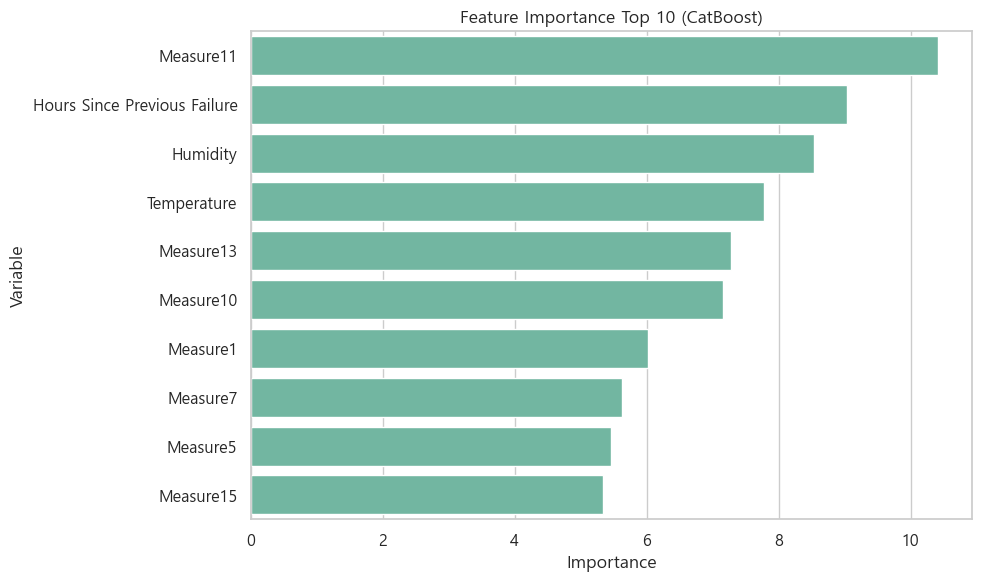

In [18]:
var_imp_cat_cls = pd.DataFrame({"Variable": Xc_train.columns, "Importance": CAT_cls.feature_importances_})
imp_top10_cat_cls = var_imp_cat_cls.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Variable", data=imp_top10_cat_cls)
plt.title("Feature Importance Top 10 (CatBoost)")
plt.tight_layout()
plt.show()

#### 하이퍼 파라미터 최적화

> CatBoost의 주요 하이퍼 파라미터:
>
> | 하이퍼파라미터 | 기본값 | 하이퍼파라미터 설명 |
> |:---:|:---:|:---:|
> | l2_leaf_reg | 3.0 | 과적합 방지를 위한 정규화 강도 |
> | random_strength | 1.0 | 트리 생성 시 랜덤성을 부여하는 정도 |
> | bagging_temperature | 1.0 | 데이터 샘플링 강도 |
> | border_count | 254 | 연속형 변수를 구간화하는 개수 |
> | iteration | 100 | 생성할 트리의 개수 |
> | depth | 6 | 트리의 최대 깊이 |
> | learning_rate | 0.1 | 각 트리가 이전 오차를 얼마나 반영할지 결정 |

In [19]:
params_cat_cls = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5],
    "l2_leaf_reg": [1, 3, 5],
    "subsample": [0.8, 1.0]
}

grid_cat_cls = GridSearchCV(
    CatBoostClassifier(random_state=0, verbose=0, bootstrap_type="Bernoulli"),
    param_grid=params_cat_cls, cv=3, scoring="f1", n_jobs=-1
)
grid_cat_cls.fit(Xc_train, Yc_train, cat_features=cat_features)

print("최적 파라미터:", grid_cat_cls.best_params_)
print("최적 F1-score (CV): %.4f" % grid_cat_cls.best_score_)

최적 파라미터: {'l2_leaf_reg': 3, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
최적 F1-score (CV): 0.8515


In [20]:
best_cat_cls_pred = grid_cat_cls.predict(Xc_test)
print("[CatBoost - 최적 모델]")
get_classscore(Yc_test, best_cat_cls_pred)

[CatBoost - 최적 모델]
Accuracy  : 0.997
Precision : 1.000
Recall    : 0.727
F1-score  : 0.842


---

## 2. 회귀 (Regression) - Concrete 데이터

> 분류에서 다룬 GBM 계열 모델들은 **회귀** 문제에도 동일하게 적용할 수 있음
> - Classifier → Regressor로 변경하고, 평가 지표를 MSE, R-squared 등으로 변경함
> - 각 모델의 하이퍼 파라미터는 분류와 동일하게 적용됨

### 데이터 전처리

In [21]:
Concrete = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day3-2_reg_data.csv"))

Y_reg = Concrete["Concrete_compressive_strength"]
X_reg = Concrete.drop(["Concrete_compressive_strength"], axis=1)

X_train_reg, X_test_reg, Y_train_reg, Y_test_reg = train_test_split(
    X_reg, Y_reg, test_size=0.3, random_state=0)

print("학습 데이터 :", X_train_reg.shape)
print("테스트 데이터 :", X_test_reg.shape)

학습 데이터 : (721, 8)
테스트 데이터 : (309, 8)


---

### 2-1) GBM

In [22]:
GBM_reg = GradientBoostingRegressor()
GBM_reg.fit(X_train_reg, Y_train_reg)
GBM_reg_pred = GBM_reg.predict(X_test_reg)
get_regscore(Y_test_reg, GBM_reg_pred)

MSE       : 26.142
RMSE      : 5.113
MAE       : 3.834
R-squared : 0.898


#### 변수 중요도 시각화

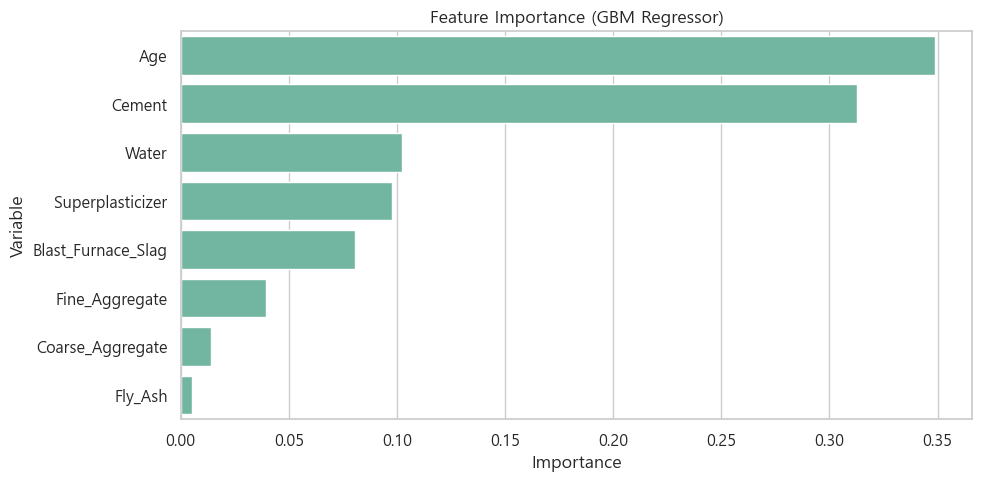

In [23]:
var_imp_gbm_reg = pd.DataFrame({"Variable": X_train_reg.columns, "Importance": GBM_reg.feature_importances_})
var_imp_gbm_reg = var_imp_gbm_reg.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x="Importance", y="Variable", data=var_imp_gbm_reg)
plt.title("Feature Importance (GBM Regressor)")
plt.tight_layout()
plt.show()

#### 하이퍼 파라미터 최적화

In [24]:
params_gbm_reg = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5],
    "min_samples_leaf": [1, 5],
    "subsample": [0.8, 1.0]
}

grid_gbm_reg = GridSearchCV(
    GradientBoostingRegressor(random_state=0),
    param_grid=params_gbm_reg, cv=3, scoring="r2", n_jobs=-1
)
grid_gbm_reg.fit(X_train_reg, Y_train_reg)

print("최적 파라미터:", grid_gbm_reg.best_params_)
print("최적 R-squared (CV): %.4f" % grid_gbm_reg.best_score_)

최적 파라미터: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 300, 'subsample': 0.8}
최적 R-squared (CV): 0.9140


In [25]:
best_gbm_reg_pred = grid_gbm_reg.predict(X_test_reg)
print("[GBM - 최적 모델]")
get_regscore(Y_test_reg, best_gbm_reg_pred)

[GBM - 최적 모델]
MSE       : 19.442
RMSE      : 4.409
MAE       : 3.069
R-squared : 0.924


---

### 2-2) XGBoost

In [26]:
XGB_reg = XGBRegressor()
XGB_reg.fit(X_train_reg, Y_train_reg)
XGB_reg_pred = XGB_reg.predict(X_test_reg)
get_regscore(Y_test_reg, XGB_reg_pred)

MSE       : 21.905
RMSE      : 4.680
MAE       : 3.158
R-squared : 0.915


#### 변수 중요도 시각화

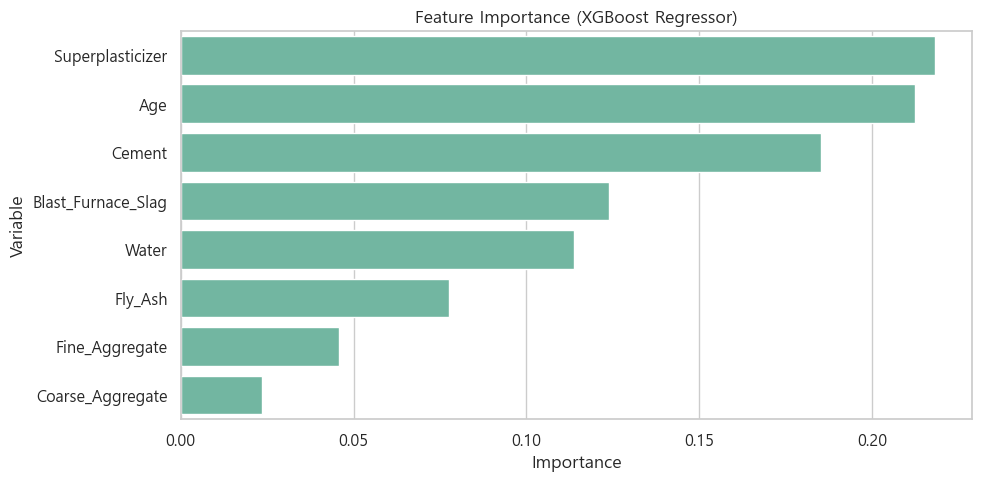

In [27]:
var_imp_xgb_reg = pd.DataFrame({"Variable": X_train_reg.columns, "Importance": XGB_reg.feature_importances_})
var_imp_xgb_reg = var_imp_xgb_reg.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x="Importance", y="Variable", data=var_imp_xgb_reg)
plt.title("Feature Importance (XGBoost Regressor)")
plt.tight_layout()
plt.show()

#### 하이퍼 파라미터 최적화

In [28]:
params_xgb_reg = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5],
    "gamma": [0, 2],
    "reg_lambda": [1, 5],
    "subsample": [0.8, 1.0]
}

grid_xgb_reg = GridSearchCV(
    XGBRegressor(random_state=0),
    param_grid=params_xgb_reg, cv=3, scoring="r2", n_jobs=-1
)
grid_xgb_reg.fit(X_train_reg, Y_train_reg)

print("최적 파라미터:", grid_xgb_reg.best_params_)
print("최적 R-squared (CV): %.4f" % grid_xgb_reg.best_score_)

최적 파라미터: {'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'reg_lambda': 1, 'subsample': 0.8}
최적 R-squared (CV): 0.9151


In [29]:
best_xgb_reg_pred = grid_xgb_reg.predict(X_test_reg)
print("[XGBoost - 최적 모델]")
get_regscore(Y_test_reg, best_xgb_reg_pred)

[XGBoost - 최적 모델]
MSE       : 20.022
RMSE      : 4.475
MAE       : 3.176
R-squared : 0.922


---

### 2-3) LightGBM

In [30]:
LGBM_reg = LGBMRegressor(verbose=-1)
LGBM_reg.fit(X_train_reg, Y_train_reg)
LGBM_reg_pred = LGBM_reg.predict(X_test_reg)
get_regscore(Y_test_reg, LGBM_reg_pred)

MSE       : 21.353
RMSE      : 4.621
MAE       : 3.244
R-squared : 0.917


#### 변수 중요도 시각화

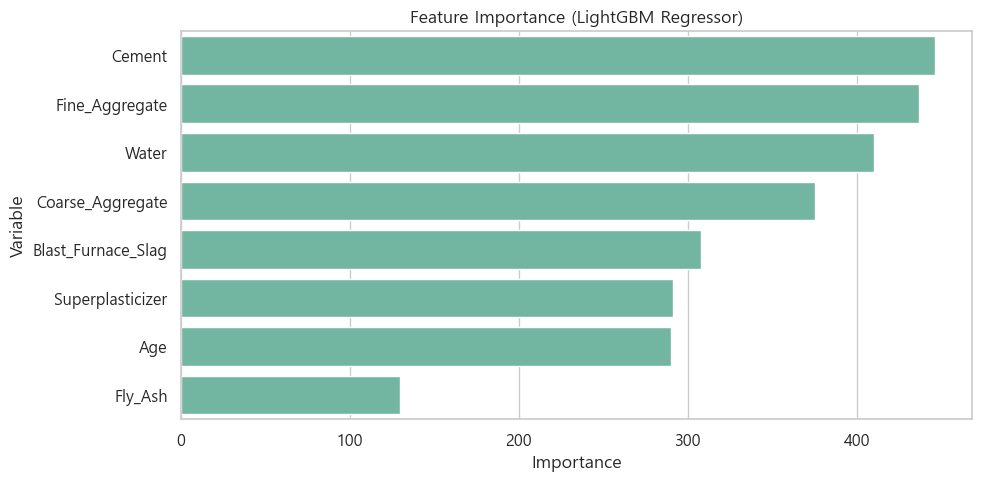

In [31]:
var_imp_lgbm_reg = pd.DataFrame({"Variable": X_train_reg.columns, "Importance": LGBM_reg.feature_importances_})
var_imp_lgbm_reg = var_imp_lgbm_reg.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x="Importance", y="Variable", data=var_imp_lgbm_reg)
plt.title("Feature Importance (LightGBM Regressor)")
plt.tight_layout()
plt.show()

#### 하이퍼 파라미터 최적화

In [32]:
params_lgbm_reg = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5],
    "num_leaves": [15, 31],
    "min_child_samples": [20, 50],
    "subsample": [0.8, 1.0]
}

grid_lgbm_reg = GridSearchCV(
    LGBMRegressor(random_state=0, verbose=-1),
    param_grid=params_lgbm_reg, cv=3, scoring="r2", n_jobs=-1
)
grid_lgbm_reg.fit(X_train_reg, Y_train_reg)

print("최적 파라미터:", grid_lgbm_reg.best_params_)
print("최적 R-squared (CV): %.4f" % grid_lgbm_reg.best_score_)

최적 파라미터: {'learning_rate': 0.1, 'max_depth': 5, 'min_child_samples': 20, 'n_estimators': 300, 'num_leaves': 15, 'subsample': 0.8}
최적 R-squared (CV): 0.9119


In [33]:
best_lgbm_reg_pred = grid_lgbm_reg.predict(X_test_reg)
print("[LightGBM - 최적 모델]")
get_regscore(Y_test_reg, best_lgbm_reg_pred)

[LightGBM - 최적 모델]
MSE       : 20.376
RMSE      : 4.514
MAE       : 3.080
R-squared : 0.921


---

### 2-4) CatBoost

In [34]:
CAT_reg = CatBoostRegressor(verbose=0)
# 해당 데이터셋에는 범주형이 없어서 따로 cat_features를 지정하지 않아도 동작 가능
CAT_reg.fit(X_train_reg, Y_train_reg)
CAT_reg_pred = CAT_reg.predict(X_test_reg)
get_regscore(Y_test_reg, CAT_reg_pred)

MSE       : 17.915
RMSE      : 4.233
MAE       : 2.778
R-squared : 0.930


#### 변수 중요도 시각화

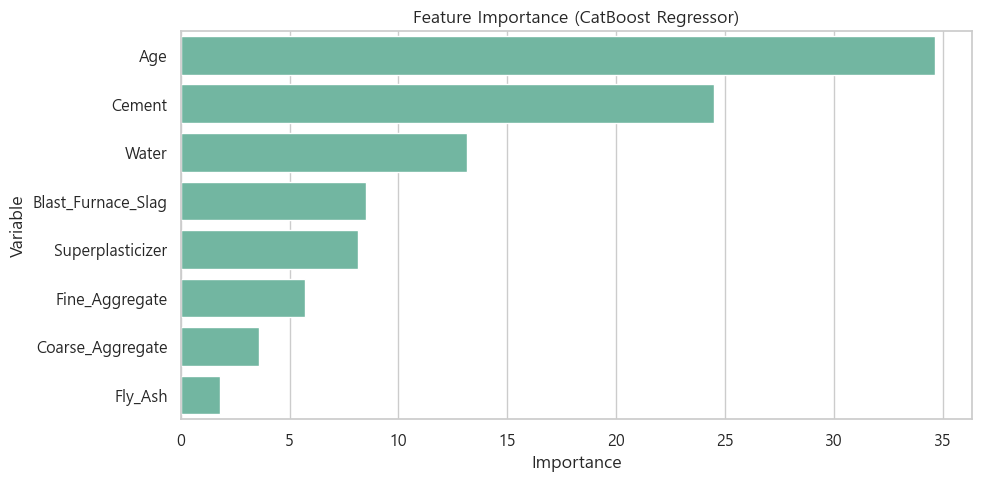

In [35]:
var_imp_cat_reg = pd.DataFrame({"Variable": X_train_reg.columns, "Importance": CAT_reg.feature_importances_})
var_imp_cat_reg = var_imp_cat_reg.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x="Importance", y="Variable", data=var_imp_cat_reg)
plt.title("Feature Importance (CatBoost Regressor)")
plt.tight_layout()
plt.show()

#### 하이퍼 파라미터 최적화

In [36]:
params_cat_reg = {
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5],
    "l2_leaf_reg": [1, 3, 5]
}

grid_cat_reg = GridSearchCV(
    CatBoostRegressor(random_state=0, verbose=0),
    param_grid=params_cat_reg, cv=3, scoring="r2"
)
grid_cat_reg.fit(X_train_reg, Y_train_reg)

print("최적 파라미터:", grid_cat_reg.best_params_)
print("최적 R-squared (CV): %.4f" % grid_cat_reg.best_score_)

최적 파라미터: {'l2_leaf_reg': 3, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}
최적 R-squared (CV): 0.9242


In [37]:
best_cat_reg_pred = grid_cat_reg.predict(X_test_reg)
print("[CatBoost - 최적 모델]")
get_regscore(Y_test_reg, best_cat_reg_pred)

[CatBoost - 최적 모델]
MSE       : 20.723
RMSE      : 4.552
MAE       : 3.117
R-squared : 0.919


---

In [38]:
best_models_cls = {
    "GBM": best_gbm_cls_pred,
    "XGBoost": best_xgb_cls_pred,
    "LightGBM": best_lgbm_cls_pred,
    "CatBoost": best_cat_cls_pred
}

best_results_cls = []
for name, pred in best_models_cls.items():
    true = Yc_test if name == "CatBoost" else Y_test
    best_results_cls.append({
        "Model": name,
        "Accuracy": round(accuracy_score(true, pred), 3),
        "Precision": round(precision_score(true, pred), 3),
        "Recall": round(recall_score(true, pred), 3),
        "F1-score": round(f1_score(true, pred), 3)
    })

pd.DataFrame(best_results_cls)

,Model,Accuracy,Precision,Recall,F1-score
0,GBM,0.997,0.944,0.773,0.850
1,XGBoost,0.997,1.000,0.727,0.842
2,LightGBM,0.997,0.941,0.727,0.821
3,CatBoost,0.997,1.000,0.727,0.842


In [39]:
best_models_reg = {
    "GBM": best_gbm_reg_pred,
    "XGBoost": best_xgb_reg_pred,
    "LightGBM": best_lgbm_reg_pred,
    "CatBoost": best_cat_reg_pred
}

best_results_reg = []
for name, pred in best_models_reg.items():
    best_results_reg.append({
        "Model": name,
        "RMSE": round(np.sqrt(mean_squared_error(Y_test_reg, pred)), 3),
        "MAE": round(mean_absolute_error(Y_test_reg, pred), 3),
        "R-squared": round(r2_score(Y_test_reg, pred), 3)
    })

pd.DataFrame(best_results_reg)

,Model,RMSE,MAE,R-squared
0,GBM,4.409,3.069,0.924
1,XGBoost,4.475,3.176,0.922
2,LightGBM,4.514,3.080,0.921
3,CatBoost,4.552,3.117,0.919


---

## 3. Vibe Coding 실습

**[과제 1]** 지수는 LightGBM이 XGBoost보다 빠르게 학습된다는 설명을 들었지만, 실제로 얼마나 차이가 나는지 궁금했습니다. AI와 상의하여 동일한 데이터셋(회귀 또는 분류)으로 XGBoost와 LightGBM을 학습시키고 학습 시간과 예측 성능을 비교해 보세요.

In [40]:
# [과제 1] XGBoost vs LightGBM 학습 시간 및 예측 성능 비교 (회귀 데이터)
common_params = {
    "n_estimators": 300,
    "learning_rate": 0.1,
    "max_depth": 3,
    "random_state": 0,
}
n_repeat = 3

time_results = []
trained_models = {}

for model_name, ModelClass, extra in [
    ("XGBoost", XGBRegressor, {}),
    ("LightGBM", LGBMRegressor, {"verbose": -1}),
]:
    train_times = []
    for _ in range(n_repeat):
        model = ModelClass(**common_params, **extra)
        start = time.perf_counter()
        model.fit(X_train_reg, Y_train_reg)
        train_times.append(time.perf_counter() - start)

    pred = model.predict(X_test_reg)
    trained_models[model_name] = model
    time_results.append({
        "모델": model_name,
        "학습 시간(초)": round(np.mean(train_times), 4),
        "RMSE": round(np.sqrt(mean_squared_error(Y_test_reg, pred)), 3),
        "MAE": round(mean_absolute_error(Y_test_reg, pred), 3),
        "R-squared": round(r2_score(Y_test_reg, pred), 3),
    })

time_compare_df = pd.DataFrame(time_results)
time_compare_df

,모델,학습 시간(초),RMSE,MAE,R-squared
0,XGBoost,0.1706,4.705,3.378,0.914
1,LightGBM,0.0433,4.689,3.334,0.914


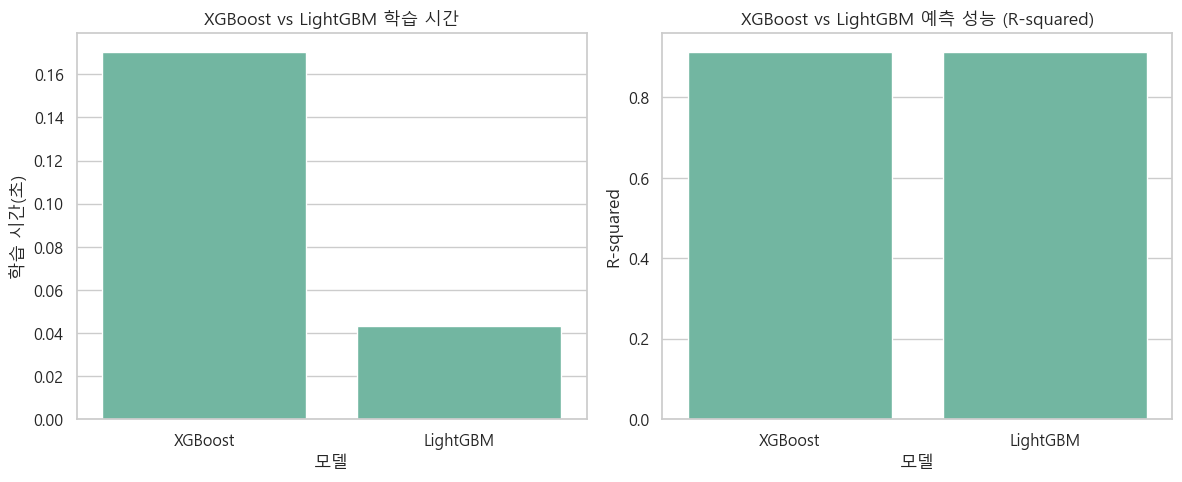

LightGBM이 XGBoost 대비 약 3.9배 빠르게 학습되었습니다.
예측 성능(R-squared)은 두 모델이 유사한 수준입니다.


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x="모델", y="학습 시간(초)", data=time_compare_df, ax=axes[0])
axes[0].set_title("XGBoost vs LightGBM 학습 시간")

sns.barplot(x="모델", y="R-squared", data=time_compare_df, ax=axes[1])
axes[1].set_title("XGBoost vs LightGBM 예측 성능 (R-squared)")

plt.tight_layout()
plt.show()

xgb_time = time_compare_df.loc[time_compare_df["모델"] == "XGBoost", "학습 시간(초)"].values[0]
lgbm_time = time_compare_df.loc[time_compare_df["모델"] == "LightGBM", "학습 시간(초)"].values[0]
print(f"LightGBM이 XGBoost 대비 약 {xgb_time / lgbm_time:.1f}배 빠르게 학습되었습니다.")
print("예측 성능(R-squared)은 두 모델이 유사한 수준입니다.")

**[과제 2]** 지수는 GBM, XGBoost, LightGBM, CatBoost가 같은 데이터를 학습했지만, 각 모델이 중요하게 판단하는 변수는 다를 수 있다고 생각했습니다. AI와 함께 회귀 또는 분류 문제에서 네 모델의 변수 중요도를 한눈에 비교할 수 있는 시각화 방법을 상의하고, 실제로 비교하여 모델 간 중요도 순위가 얼마나 일치하는지 확인해 보세요.

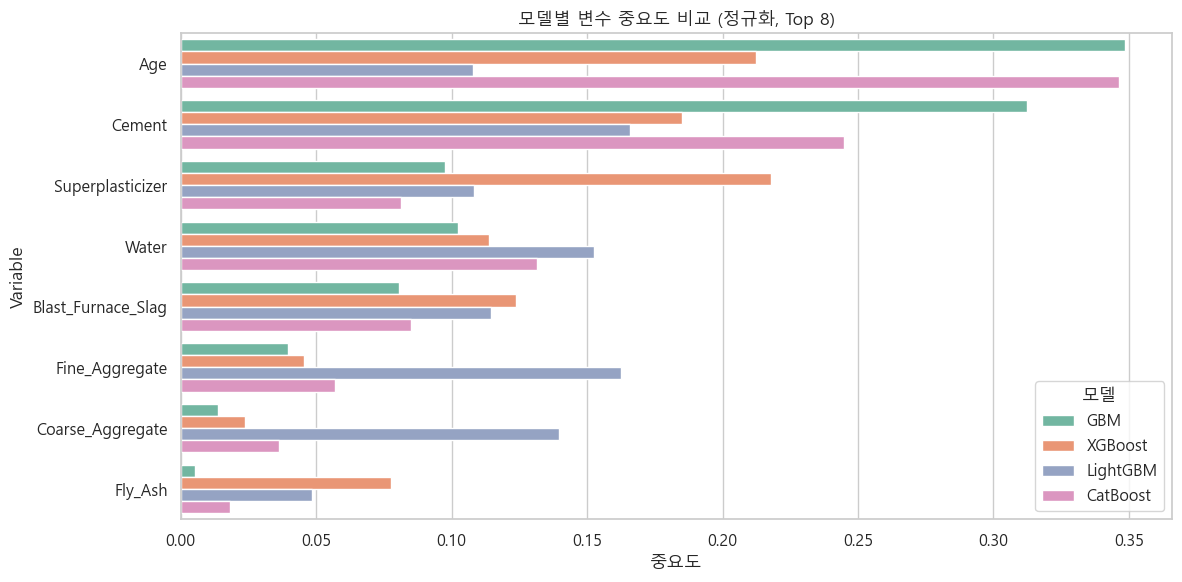

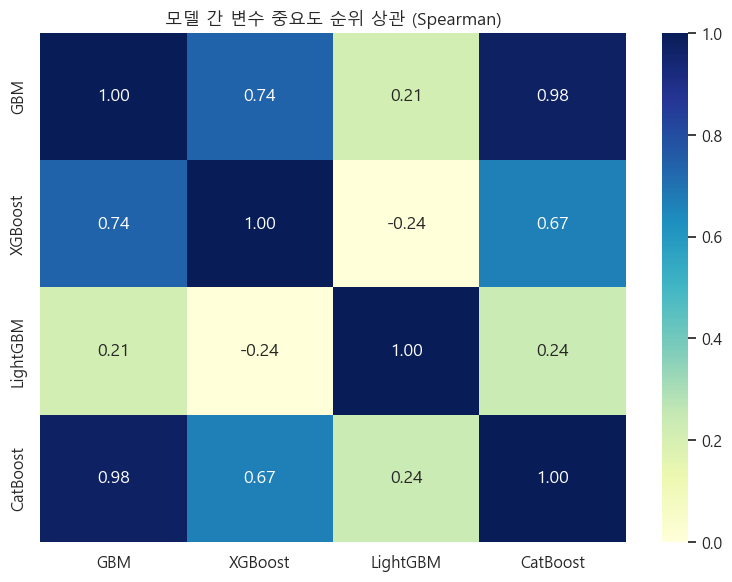

,GBM,XGBoost,LightGBM,CatBoost
GBM,1.000000,0.738095,0.214286,0.976190
XGBoost,0.738095,1.000000,-0.238095,0.666667
LightGBM,0.214286,-0.238095,1.000000,0.238095
CatBoost,0.976190,0.666667,0.238095,1.000000


In [42]:
# [과제 2] 4개 모델 변수 중요도 비교 (회귀)
importance_dfs = {
    "GBM": var_imp_gbm_reg.set_index("Variable")["Importance"],
    "XGBoost": var_imp_xgb_reg.set_index("Variable")["Importance"],
    "LightGBM": var_imp_lgbm_reg.set_index("Variable")["Importance"],
    "CatBoost": var_imp_cat_reg.set_index("Variable")["Importance"],
}

imp_merged = pd.DataFrame(importance_dfs).fillna(0)
imp_merged_norm = imp_merged.div(imp_merged.sum(axis=0), axis=1)
imp_merged_norm["평균"] = imp_merged_norm.mean(axis=1)

top_vars = imp_merged_norm.sort_values("평균", ascending=False).head(8).index
imp_plot = (
    imp_merged_norm.loc[top_vars]
    .drop(columns=["평균"])
    .reset_index()
    .melt(id_vars="Variable", var_name="모델", value_name="중요도")
)

plt.figure(figsize=(12, 6))
sns.barplot(x="중요도", y="Variable", hue="모델", data=imp_plot)
plt.title("모델별 변수 중요도 비교 (정규화, Top 8)")
plt.tight_layout()
plt.show()

rank_corr = imp_merged_norm.drop(columns=["평균"]).rank(ascending=False).corr(method="spearman")

plt.figure(figsize=(8, 6))
sns.heatmap(rank_corr, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1)
plt.title("모델 간 변수 중요도 순위 상관 (Spearman)")
plt.tight_layout()
plt.show()

rank_corr

**[과제 3]** 지수는 여러 머신러닝 모델의 예측 결과를 결합하는 Stacking Ensemble이라는 방법을 알게 되었고, Stacking 모델이 단일 앙상블 모델보다 항상 더 좋은 성능을 보이는지 궁금해졌습니다. AI와 상의하여 결합할 모델들을 선택해 Stacking 모델을 구축해 보세요. 이후 Stacking 모델과 각 단일 앙상블 모델의 성능을 비교해 보세요.

In [68]:
# [과제 3] 앙상블 기법 종합 비교 (회귀)
from sklearn.ensemble import (
    StackingRegressor, VotingRegressor,
    BaggingRegressor, RandomForestRegressor, ExtraTreesRegressor,
    AdaBoostRegressor, HistGradientBoostingRegressor,
)
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor

base_models = [
    ("GBM", grid_gbm_reg.best_estimator_),
    ("XGBoost", grid_xgb_reg.best_estimator_),
    ("LightGBM", grid_lgbm_reg.best_estimator_),
    ("CatBoost", grid_cat_reg.best_estimator_),
]

combine_ensemble_names = {
    "Stacking", "단순 평균", "가중 평균 (CV)", "중앙값 앙상블",
    "VotingRegressor", "Voting (가중)",
}
sklearn_ensemble_names = {
    "Bagging", "Random Forest", "Extra Trees", "AdaBoost", "HistGradientBoosting",
}


def append_result(results, name, pred, category, train_time=None):
    results.append({
        "모델": name,
        "유형": category,
        "학습시간(초)": round(train_time, 2) if train_time is not None else np.nan,
        "RMSE": round(np.sqrt(mean_squared_error(Y_test_reg, pred)), 3),
        "MAE": round(mean_absolute_error(Y_test_reg, pred), 3),
        "R-squared": round(r2_score(Y_test_reg, pred), 3),
    })


ensemble_compare = []

# --- A) 단일 모델 (튜닝 완료) ---
for name, pred in [
    ("GBM", best_gbm_reg_pred),
    ("XGBoost", best_xgb_reg_pred),
    ("LightGBM", best_lgbm_reg_pred),
    ("CatBoost", best_cat_reg_pred),
]:
    append_result(ensemble_compare, name, pred, "단일")

# --- B) 결합 앙상블: 기존 4모델 예측 결합 ---
base_pred_dict = {
    "GBM": best_gbm_reg_pred,
    "XGBoost": best_xgb_reg_pred,
    "LightGBM": best_lgbm_reg_pred,
    "CatBoost": best_cat_reg_pred,
}
pred_matrix = np.column_stack(list(base_pred_dict.values()))
pred_corr = pd.DataFrame(base_pred_dict).corr()

simple_avg_pred = pred_matrix.mean(axis=1)
cv_weights = np.array([
    grid_gbm_reg.best_score_,
    grid_xgb_reg.best_score_,
    grid_lgbm_reg.best_score_,
    grid_cat_reg.best_score_,
])
cv_weights = cv_weights / cv_weights.sum()
weighted_avg_pred = pred_matrix @ cv_weights
median_pred = np.median(pred_matrix, axis=1)

stack_reg = StackingRegressor(
    estimators=base_models, final_estimator=Ridge(), cv=3, n_jobs=-1,
)
start = time.perf_counter()
stack_reg.fit(X_train_reg, Y_train_reg)
stack_train_time = time.perf_counter() - start
stack_pred = stack_reg.predict(X_test_reg)

voting_reg = VotingRegressor(estimators=base_models, n_jobs=-1)
start = time.perf_counter()
voting_reg.fit(X_train_reg, Y_train_reg)
voting_train_time = time.perf_counter() - start
voting_pred = voting_reg.predict(X_test_reg)

voting_weighted_reg = VotingRegressor(
    estimators=base_models, weights=cv_weights.tolist(), n_jobs=-1,
)
start = time.perf_counter()
voting_weighted_reg.fit(X_train_reg, Y_train_reg)
voting_weighted_train_time = time.perf_counter() - start
voting_weighted_pred = voting_weighted_reg.predict(X_test_reg)

for name, pred, t in [
    ("Stacking", stack_pred, stack_train_time),
    ("단순 평균", simple_avg_pred, None),
    ("가중 평균 (CV)", weighted_avg_pred, None),
    ("중앙값 앙상블", median_pred, None),
    ("VotingRegressor", voting_pred, voting_train_time),
    ("Voting (가중)", voting_weighted_pred, voting_weighted_train_time),
]:
    append_result(ensemble_compare, name, pred, "결합 앙상블", t)

# --- C) sklearn.ensemble 내장 앙상블 ---
sklearn_ensemble_models = [
    ("Bagging", BaggingRegressor(
        estimator=DecisionTreeRegressor(max_depth=8, random_state=0),
        n_estimators=100, random_state=0, n_jobs=-1,
    )),
    ("Random Forest", RandomForestRegressor(
        n_estimators=300, max_depth=8, random_state=0, n_jobs=-1,
    )),
    ("Extra Trees", ExtraTreesRegressor(
        n_estimators=300, max_depth=8, random_state=0, n_jobs=-1,
    )),
    ("AdaBoost", AdaBoostRegressor(n_estimators=100, random_state=0)),
    ("HistGradientBoosting", HistGradientBoostingRegressor(
        max_iter=300, max_depth=8, random_state=0,
    )),
]

for name, model in sklearn_ensemble_models:
    start = time.perf_counter()
    model.fit(X_train_reg, Y_train_reg)
    train_time = time.perf_counter() - start
    append_result(ensemble_compare, name, model.predict(X_test_reg), "sklearn 앙상블", train_time)

ensemble_compare_df = pd.DataFrame(ensemble_compare).sort_values("R-squared", ascending=False)
stack_compare_df = ensemble_compare_df.copy()
ensemble_compare_df

,모델,유형,학습시간(초),RMSE,MAE,R-squared
14,HistGradientBoosting,sklearn 앙상블,0.56,4.226,2.813,0.930
8,VotingRegressor,결합 앙상블,6.45,4.301,2.956,0.928
9,Voting (가중),결합 앙상블,6.69,4.302,2.956,0.928
5,단순 평균,결합 앙상블,NaN,4.321,2.984,0.927
6,가중 평균 (CV),결합 앙상블,NaN,4.322,2.984,0.927
7,중앙값 앙상블,결합 앙상블,NaN,4.376,2.993,0.925
0,GBM,단일,NaN,4.409,3.069,0.924
1,XGBoost,단일,NaN,4.475,3.176,0.922
4,Stacking,결합 앙상블,30.36,4.464,3.076,0.922
2,LightGBM,단일,NaN,4.514,3.080,0.921


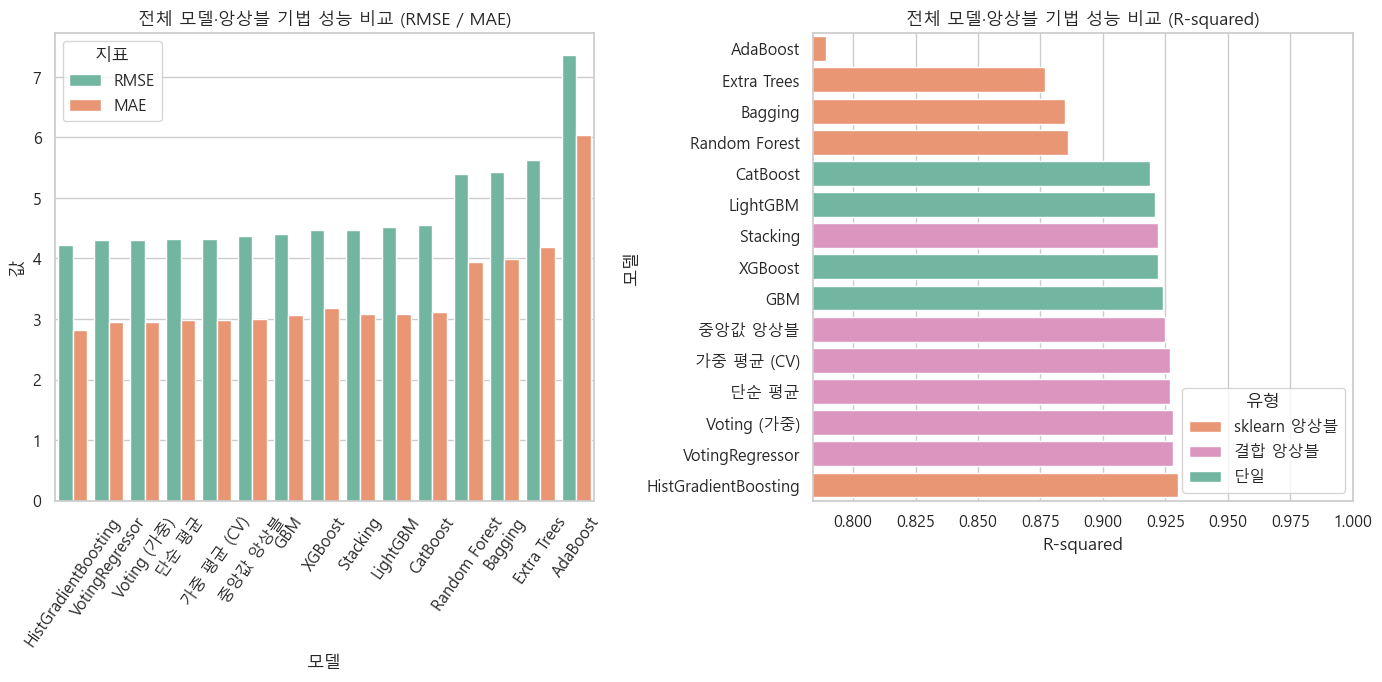

단일 최고      : GBM (R²=0.924)
결합 앙상블 최고: VotingRegressor (R²=0.928)
sklearn 최고   : HistGradientBoosting (R²=0.93)
전체 1위       : HistGradientBoosting (R²=0.93)


In [72]:
type_palette = {
    "단일": sns.color_palette("Set2")[0],
    "결합 앙상블": sns.color_palette("Set2")[3],
    "sklearn 앙상블": sns.color_palette("Set2")[1],
}
plot_order = ensemble_compare_df.sort_values("R-squared", ascending=False)["모델"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

ensemble_melt = ensemble_compare_df.melt(
    id_vars=["모델", "유형"], value_vars=["RMSE", "MAE"], var_name="지표", value_name="값"
)
sns.barplot(
    x="모델", y="값", hue="지표", data=ensemble_melt,
    order=plot_order, ax=axes[0],
)
axes[0].set_title("전체 모델·앙상블 기법 성능 비교 (RMSE / MAE)")
axes[0].tick_params(axis="x", rotation=55)

sns.barplot(
    x="R-squared", y="모델", hue="유형", data=ensemble_compare_df,
    order=plot_order[::-1], dodge=False, palette=type_palette, ax=axes[1],
)
axes[1].set_title("전체 모델·앙상블 기법 성능 비교 (R-squared)")
axes[1].set_xlim(ensemble_compare_df["R-squared"].min() - 0.005, 1.0)
axes[1].legend(title="유형", loc="lower right")

plt.tight_layout()
plt.show()

best_single = ensemble_compare_df[ensemble_compare_df["유형"] == "단일"].iloc[0]
best_combine = ensemble_compare_df[ensemble_compare_df["유형"] == "결합 앙상블"].iloc[0]
best_sklearn = ensemble_compare_df[ensemble_compare_df["유형"] == "sklearn 앙상블"].iloc[0]

print(f"단일 최고      : {best_single['모델']} (R²={best_single['R-squared']})")
print(f"결합 앙상블 최고: {best_combine['모델']} (R²={best_combine['R-squared']})")
print(f"sklearn 최고   : {best_sklearn['모델']} (R²={best_sklearn['R-squared']})")
print(f"전체 1위       : {ensemble_compare_df.iloc[0]['모델']} (R²={ensemble_compare_df.iloc[0]['R-squared']})")

### 추가: sklearn.ensemble 앙상블 기법 확장 비교

| 유형 | 기법 | 설명 |
|------|------|------|
| **결합** | Stacking | 메타 학습기(Ridge)로 4개 모델 예측 결합 |
| **결합** | 단순/가중/중앙값 평균 | 예측값 직접 결합 (가중치 = CV R²) |
| **결합** | VotingRegressor / Voting (가중) | sklearn 투표 앙상블 (동일·CV 가중) |
| **sklearn** | Bagging | 부트스트랩 샘플 + DecisionTree 앙상블 |
| **sklearn** | Random Forest | 배깅 + 변수 무작위 선택 |
| **sklearn** | Extra Trees | 무작위 분할 + 극단적 무작위성 |
| **sklearn** | AdaBoost | 약한 학습기 순차 가중치 부여 |
| **sklearn** | HistGradientBoosting | 히스토그램 기반 그래디언트 부스팅 |

In [73]:
# 유형별 성능 요약 & CV 가중치
print("=== 유형별 평균 R-squared ===")
print(ensemble_compare_df.groupby("유형")["R-squared"].agg(["mean", "max", "count"]).round(3))

print("\n=== CV R² 기반 가중치 (결합 앙상블용) ===")
for name, w in zip(base_pred_dict.keys(), cv_weights):
    print(f"  {name}: {w:.3f}")

print("\n=== sklearn 앙상블 학습 시간 ===")
sklearn_time_df = ensemble_compare_df[
    ensemble_compare_df["유형"] == "sklearn 앙상블"
][["모델", "학습시간(초)", "R-squared"]].sort_values("R-squared", ascending=False)
sklearn_time_df

=== 유형별 평균 R-squared ===
              mean    max  count
유형                              
sklearn 앙상블  0.873  0.930      5
결합 앙상블       0.926  0.928      6
단일           0.922  0.924      4

=== CV R² 기반 가중치 (결합 앙상블용) ===
  GBM: 0.249
  XGBoost: 0.250
  LightGBM: 0.249
  CatBoost: 0.252

=== sklearn 앙상블 학습 시간 ===


,모델,학습시간(초),R-squared
14,HistGradientBoosting,0.56,0.930
11,Random Forest,0.48,0.886
10,Bagging,0.14,0.885
12,Extra Trees,0.30,0.877
13,AdaBoost,0.21,0.789


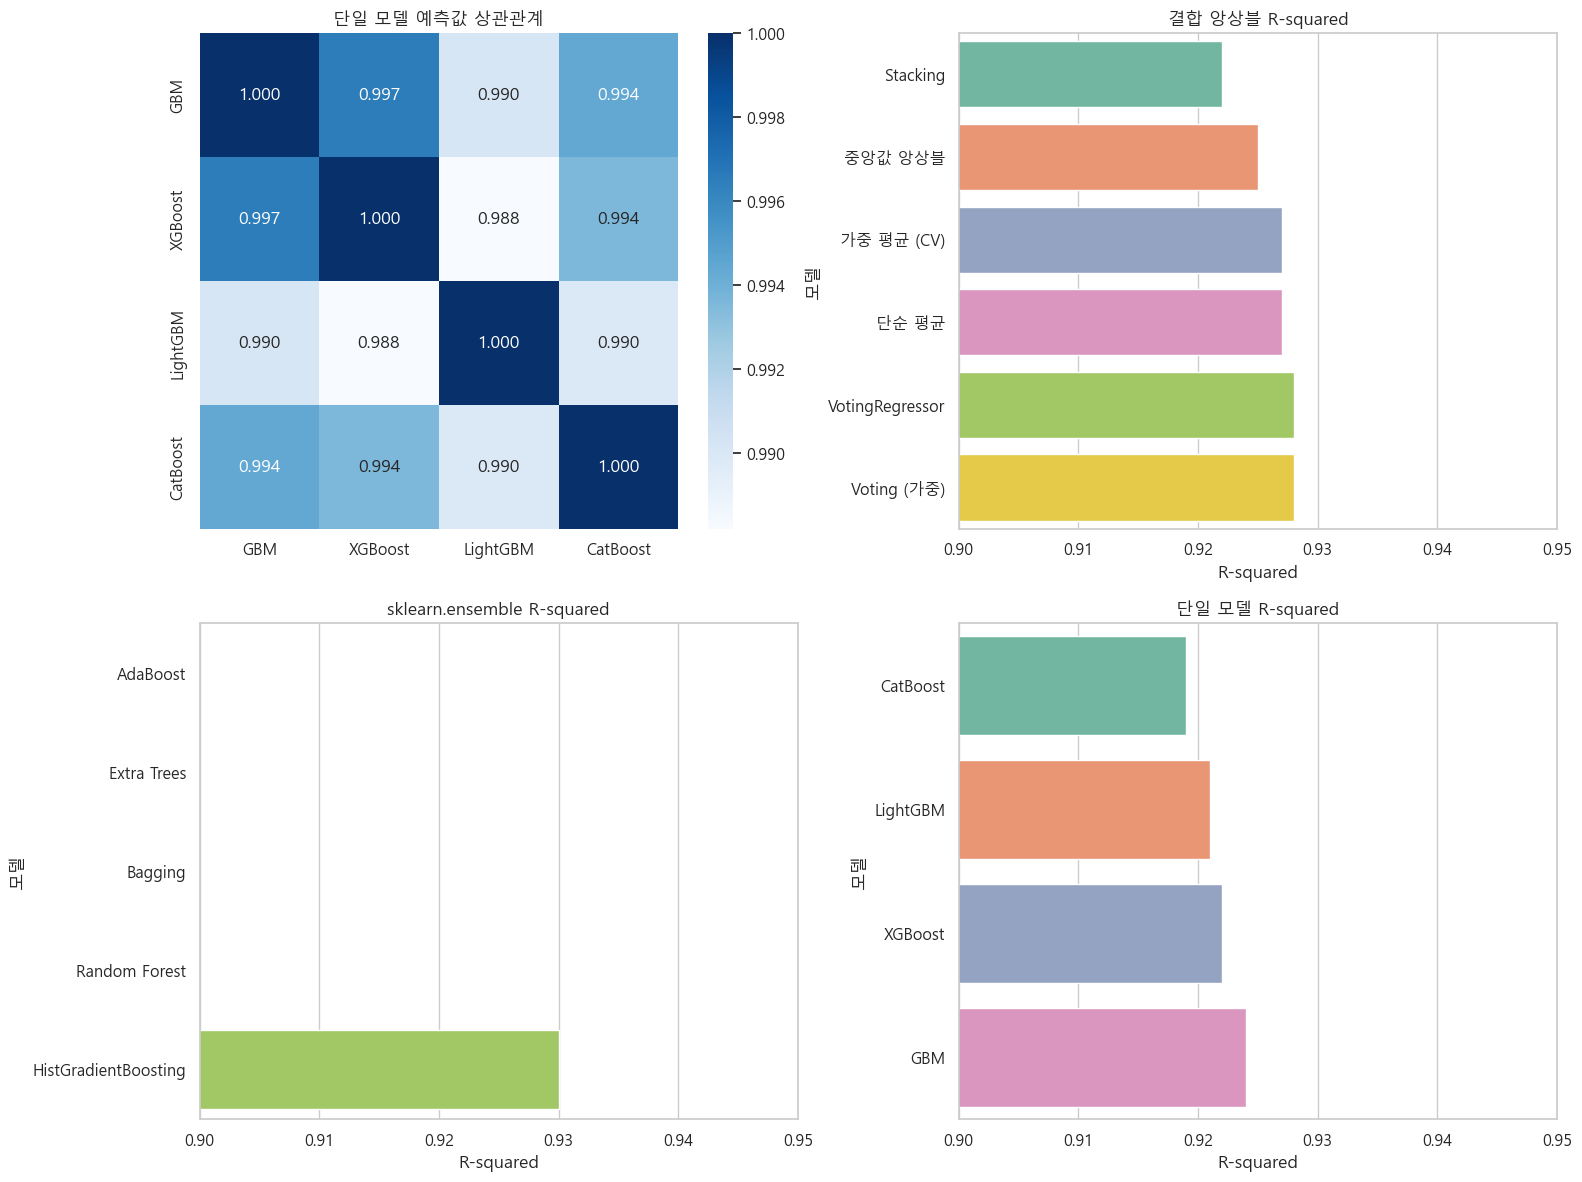

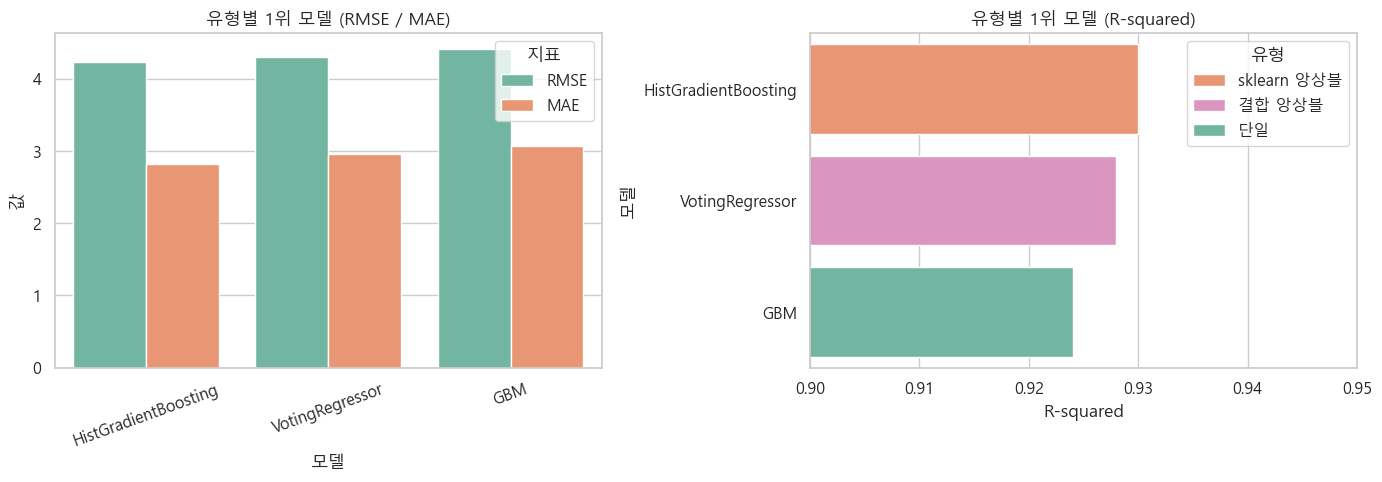

Stacking R²=0.922 | 결합 1위 VotingRegressor R²=0.928
sklearn 1위 HistGradientBoosting R²=0.93


In [77]:
# 유형별 세부 비교 차트
type_palette = {
    "단일": sns.color_palette("Set2")[0],
    "결합 앙상블": sns.color_palette("Set2")[3],
    "sklearn 앙상블": sns.color_palette("Set2")[1],
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.heatmap(pred_corr, annot=True, fmt=".3f", cmap="Blues", ax=axes[0, 0])
axes[0, 0].set_title("단일 모델 예측값 상관관계")

for ax, category, title in zip(
    [axes[0, 1], axes[1, 0], axes[1, 1]],
    ["결합 앙상블", "sklearn 앙상블", "단일"],
    ["결합 앙상블 R-squared", "sklearn.ensemble R-squared", "단일 모델 R-squared"],
):
    sub = ensemble_compare_df[ensemble_compare_df["유형"] == category].sort_values("R-squared")
    sns.barplot(
        x="R-squared", y="모델", data=sub, ax=ax,
        hue="모델", palette="Set2", legend=False,
    )
    ax.set_title(title)
    ax.set_xlim(0.90, 0.95)

plt.tight_layout()
plt.show()

# 유형별 Top-1 비교
top_by_type = (
    ensemble_compare_df.sort_values("R-squared", ascending=False)
    .groupby("유형", as_index=False)
    .first()
)
top_melt = top_by_type.melt(id_vars=["유형", "모델"], value_vars=["RMSE", "MAE"], var_name="지표", value_name="값")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x="모델", y="값", hue="지표", data=top_melt, ax=axes[0])
axes[0].set_title("유형별 1위 모델 (RMSE / MAE)")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(
    x="R-squared", y="모델", hue="유형", data=top_by_type,
    dodge=False, palette=type_palette, ax=axes[1],
)
axes[1].set_title("유형별 1위 모델 (R-squared)")
axes[1].set_xlim(0.90, 0.95)
plt.tight_layout()
plt.show()

stack_row = ensemble_compare_df.loc[ensemble_compare_df["모델"] == "Stacking"].iloc[0]
best_combine = ensemble_compare_df[ensemble_compare_df["유형"] == "결합 앙상블"].iloc[0]
best_sklearn = ensemble_compare_df[ensemble_compare_df["유형"] == "sklearn 앙상블"].iloc[0]
print(f"Stacking R²={stack_row['R-squared']} | 결합 1위 {best_combine['모델']} R²={best_combine['R-squared']}")
print(f"sklearn 1위 {best_sklearn['모델']} R²={best_sklearn['R-squared']}")